# Notebook 14 - Property Group ML Modelling

## Airbnb Capstone | Sponsor Follow-Up Experiment

The company sponsor suggested that prices may behave differently across property types. This notebook tests that idea by training the same supervised regression model families separately for the larger `property_group` segments in Madrid and Tokyo.

**Goal:** compare the current city-level modelling approach against property-group-specific models.

**Important modelling idea:** the target is still `log_price_eur`, because log-transforming price reduces skew. The new experiment tests a separate question: whether each property group follows a different pricing regime.

---
## 1. Setup and Imports

In [1]:
import importlib.util
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import is_numeric_dtype
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

if importlib.util.find_spec("xgboost"):
    from xgboost import XGBRegressor
else:
    XGBRegressor = None

if importlib.util.find_spec("lightgbm"):
    from lightgbm import LGBMRegressor
else:
    LGBMRegressor = None

if importlib.util.find_spec("catboost"):
    from catboost import CatBoostRegressor
else:
    CatBoostRegressor = None

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
MODEL_N_JOBS = -1
TARGET_COL = "log_price_eur"
PRICE_COL = "price_eur"
SEGMENT_COL = "property_group"
MIN_SEGMENT_ROWS = 300
MIN_TEST_ROWS = 60

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")

print("Libraries loaded.")
print("Optional model availability:")
print("- XGBoost:", XGBRegressor is not None)
print("- LightGBM:", LGBMRegressor is not None)
print("- CatBoost:", CatBoostRegressor is not None)

Libraries loaded.
Optional model availability:
- XGBoost: True
- LightGBM: True
- CatBoost: True


This cell imports the modelling libraries and checks which optional gradient-boosting packages are available. We keep the same 80/20 split and `random_state=42` used in the city-level modelling work.

---
## 2. Project Paths

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until the CAPSTONE project folders are found."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "1. Data").exists() and (candidate / "2. Code").exists():
            return candidate
    raise FileNotFoundError("Could not find the CAPSTONE project root.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "1. Data"
MODEL_READY_DIR = DATA_DIR / "model_ready"
OUTPUT_DIR = DATA_DIR / "Outputs" / "ml_models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CITY_FILES = {
    "Madrid": MODEL_READY_DIR / "madrid_model_ready.csv",
    "Tokyo": MODEL_READY_DIR / "tokyo_model_ready.csv",
}

print("Project root:", PROJECT_ROOT)
print("Model-ready folder:", MODEL_READY_DIR)
print("Output folder:", OUTPUT_DIR)

Project root: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE
Model-ready folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\model_ready
Output folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models


This cell finds the project root automatically, so the notebook can be opened from different working directories. Outputs are saved back into `1. Data/Outputs/ml_models`.

---
## 3. Load Model-Ready Data

In [3]:
def load_city_model_ready(city_files: dict[str, Path]) -> dict[str, pd.DataFrame]:
    """Load one model-ready dataset per city and add a traceable row id."""
    datasets = {}
    for city, path in city_files.items():
        df = pd.read_csv(path).reset_index(drop=True)
        df.insert(0, "model_ready_row", np.arange(len(df)))
        datasets[city] = df
    return datasets

city_data = load_city_model_ready(CITY_FILES)

for city, df in city_data.items():
    print(f"{city}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")
    display(df.head(3))

Madrid: 17,770 rows, 88 columns


,model_ready_row,price_eur,log_price_eur,neighbourhood_cleansed,neighbourhood_group,property_group,room_type,bathroom_type,capacity_bucket,host_response_time,host_scale_bucket,review_recency_bucket,latitude,longitude,distance_to_center_km,is_central_5km,neighbourhood_listing_count,accommodates,bedrooms,beds,bathrooms,amenities_count,has_wifi,has_kitchen,has_air_conditioning,has_washer,has_dedicated_workspace,has_tv,has_parking,has_elevator,has_heating,has_self_checkin,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_tenure_days,days_since_last_review,review_history_days,has_reviews,minimum_nights_capped,is_professional_host,calendar_unavailable_rate,calendar_unavailable_q1,calendar_unavailable_q2,calendar_unavailable_q3,calendar_unavailable_q4,calendar_unavailable_autumn,calendar_unavailable_spring,calendar_unavailable_summer,calendar_unavailable_winter,calendar_unavailable_weekday,calendar_unavailable_weekend,beds_per_guest,bathrooms_per_guest,reviews_last_6m,has_rating,reviewed_last_30d,reviewed_last_90d,low_availability_30,high_annual_availability,availability_30_ratio,availability_365_ratio,calendar_weekend_unavailable_gap
0,0,157.0000,5.0626,Sol,Centro,Apartment/condo,Entire home/apt,Standard,couple,within an hour,professional_host,reviewed_30d,40.4148,-3.7042,0.2291,1,994,2,1.0000,2.0000,1.0000,6,1,1,1,0,0,1,0,1,1,0,1.0000,1.0000,0.0000,17.0000,1.0000,1.0000,50,16,46,76,342,173,1,1,0,4.6300,4.7100,4.8800,4.8200,4.7800,4.9000,4.6900,1.0000,17,17,0,0,0.9300,5593.0000,19.0000,5531.0000,1,5,1,0.0630,0.0333,0.0000,0.1522,0.0652,0.1538,0.0000,0.0000,0.1000,0.0613,0.0673,1.0000,0.5000,1.0000,1,1,1,0,1,0.5333,0.9370,0.0060
1,1,143.0000,4.9698,Universidad,Centro,Apartment/condo,Entire home/apt,Standard,couple,within an hour,professional_host,reviewed_30d,40.4225,-3.7058,0.6522,1,1566,2,1.0000,3.0000,1.0000,6,1,1,1,0,0,1,0,1,1,0,1.0000,1.0000,0.0000,17.0000,1.0000,1.0000,50,10,40,66,341,53,4,1,0,4.6800,4.7100,4.9000,4.8700,4.8100,4.8800,4.5900,1.0000,17,17,0,0,0.2900,5593.0000,4.0000,5428.0000,1,5,1,0.0658,0.0000,0.0000,0.1739,0.0870,0.2527,0.0000,0.0000,0.0111,0.0651,0.0673,1.5000,0.5000,4.0000,1,1,1,0,1,0.3333,0.9342,0.0022
2,2,65.0000,4.1897,Justicia,Centro,Apartment/condo,Private room,Shared,small_group,within an hour,small_multi_host,reviewed_30d,40.4188,-3.6965,0.6543,1,861,4,1.0000,2.0000,1.5000,32,1,1,0,1,1,0,0,0,1,0,1.0000,0.9900,0.0000,3.0000,1.0000,1.0000,30,4,16,34,299,249,41,4,45,4.6500,4.7800,4.4600,4.8000,4.8600,4.9700,4.6000,0.0000,3,1,2,0,2.7800,5404.0000,10.0000,2675.0000,1,1,0,0.1808,0.0556,0.0000,0.1522,0.5109,0.6154,0.0543,0.0000,0.0556,0.1724,0.2019,0.5000,0.3750,21.0000,1,1,1,1,1,0.1333,0.8192,0.0295


Tokyo: 23,765 rows, 87 columns


,model_ready_row,price_eur,log_price_eur,neighbourhood_cleansed,property_group,room_type,bathroom_type,capacity_bucket,host_response_time,host_scale_bucket,review_recency_bucket,latitude,longitude,distance_to_center_km,is_central_5km,neighbourhood_listing_count,accommodates,bedrooms,beds,bathrooms,amenities_count,has_wifi,has_kitchen,has_air_conditioning,has_washer,has_dedicated_workspace,has_tv,has_parking,has_elevator,has_heating,has_self_checkin,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_tenure_days,days_since_last_review,review_history_days,has_reviews,minimum_nights_capped,is_professional_host,calendar_unavailable_rate,calendar_unavailable_q1,calendar_unavailable_q2,calendar_unavailable_q3,calendar_unavailable_q4,calendar_unavailable_autumn,calendar_unavailable_spring,calendar_unavailable_summer,calendar_unavailable_winter,calendar_unavailable_weekday,calendar_unavailable_weekend,beds_per_guest,bathrooms_per_guest,reviews_last_6m,has_rating,reviewed_last_30d,reviewed_last_90d,low_availability_30,high_annual_availability,availability_30_ratio,availability_365_ratio,calendar_weekend_unavailable_gap
0,0,78.1200,4.3710,Sumida Ku,Apartment/condo,Entire home/apt,Standard,couple,within a day,single_listing,reviewed_90d,35.7171,139.8261,6.6539,0,3478,2,1.0000,2.0000,1.0000,21,1,1,1,1,0,1,0,0,1,1,1.0000,0.8900,1.0000,1.0000,1.0000,1.0000,1125,5,22,27,183,190,10,0,9,4.7800,4.7600,4.9100,4.8500,4.8400,4.5800,4.8000,0.0000,1,1,0,0,1.1100,5162.0000,37.0000,5086.0000,1,3,0,0.4986,0.4667,0.7363,0.0870,0.7065,0.4176,0.8043,0.3370,0.4333,0.4904,0.5192,1.0000,0.5000,7.0000,1,0,1,1,0,0.1667,0.5014,0.0288
1,1,64.8458,4.1873,Kita Ku,House/villa,Private room,Shared,solo,within an hour,single_listing,reviewed_365d,35.7384,139.7692,6.3675,0,771,1,1.0000,1.0000,1.0000,22,1,0,1,0,0,1,0,0,1,0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,14,0,0,0,76,272,14,0,15,4.9800,4.9700,4.9200,4.9800,4.9800,4.8500,4.9200,0.0000,1,0,1,0,1.7400,5195.0000,131.0000,4557.0000,1,3,0,0.7918,1.0000,0.1648,1.0000,1.0000,1.0000,0.4565,0.7174,1.0000,0.7893,0.7981,1.0000,1.0000,6.0000,1,0,0,1,0,0.0000,0.2082,0.0088
2,2,208.7602,5.3460,Shibuya Ku,Apartment/condo,Entire home/apt,Standard,family_group,within an hour,professional_host,reviewed_30d,35.6788,139.6785,8.0098,0,1502,6,2.0000,4.0000,1.5000,41,1,1,1,0,0,1,1,0,1,1,1.0000,1.0000,1.0000,9.0000,1.0000,1.0000,1125,2,10,40,305,281,50,3,42,4.8200,4.8300,4.8200,4.8900,4.9300,4.8100,4.8100,1.0000,9,9,0,0,1.8500,4630.0000,8.0000,4550.0000,1,5,1,0.1644,0.0667,0.0000,0.0217,0.5652,0.5495,0.0000,0.0000,0.1111,0.1571,0.1827,0.6667,0.2500,24.0000,1,1,1,1,1,0.0667,0.8356,0.0256


This cell loads the existing `model_ready` CSVs. The `model_ready_row` column preserves the original row number so predictions can be traced back to the source dataset if needed.

---
## 4. Audit Property Group Sizes

In [4]:
def audit_property_groups(datasets: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Count rows by city and property group, then mark whether a segment is modelled."""
    rows = []
    for city, df in datasets.items():
        split_labels = pd.Series("train", index=df.index)
        _, test_index = train_test_split(df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE)
        split_labels.loc[test_index] = "test"
        working = df.assign(split=split_labels)

        grouped = (
            working.groupby(SEGMENT_COL, dropna=False)
            .agg(
                rows=(SEGMENT_COL, "size"),
                train_rows=("split", lambda s: int((s == "train").sum())),
                test_rows=("split", lambda s: int((s == "test").sum())),
                median_price_eur=(PRICE_COL, "median"),
                mean_price_eur=(PRICE_COL, "mean"),
            )
            .reset_index()
        )
        grouped.insert(0, "city", city)
        rows.append(grouped)

    audit = pd.concat(rows, ignore_index=True)
    audit["model_status"] = np.where(
        (audit["rows"] >= MIN_SEGMENT_ROWS) & (audit["test_rows"] >= MIN_TEST_ROWS),
        "Modelled",
        "Skipped - too few rows",
    )
    audit["median_price_eur"] = audit["median_price_eur"].round(2)
    audit["mean_price_eur"] = audit["mean_price_eur"].round(2)
    return audit.sort_values(["city", "rows"], ascending=[True, False])

segment_audit = audit_property_groups(city_data)
display(segment_audit)

,city,property_group,rows,train_rows,test_rows,median_price_eur,mean_price_eur,model_status
0,Madrid,Apartment/condo,15892,12691,3201,107.0000,116.1000,Modelled
3,Madrid,House/villa,772,630,142,55.0000,77.9100,Modelled
2,Madrid,Hotel/serviced,516,410,106,135.0000,143.1400,Modelled
1,Madrid,Guesthouse/hostel,402,332,70,95.5000,105.0300,Modelled
5,Madrid,Room,134,109,25,52.5000,64.0600,Skipped - too few rows
4,Madrid,Other,54,44,10,103.0000,120.3100,Skipped - too few rows
6,Tokyo,Apartment/condo,17500,14014,3486,91.7600,104.0500,Modelled
9,Tokyo,House/villa,4209,3350,859,127.5500,134.3800,Modelled
8,Tokyo,Hotel/serviced,1504,1202,302,107.9500,124.6700,Modelled
7,Tokyo,Guesthouse/hostel,336,271,65,38.2000,52.6600,Modelled


This audit decides which property groups are large enough for separate models. `Room` and `Other` are expected to be skipped because their holdout samples are too small for reliable evaluation.

---
## 5. Modelling Utility Functions

In [5]:
def make_one_hot_encoder() -> OneHotEncoder:
    """Create an encoder that works across older and newer sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(numeric_cols: list[str], categorical_cols: list[str], scale_numeric: bool = False) -> ColumnTransformer:
    """Create the numeric/categorical preprocessing pipeline."""
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(steps=numeric_steps), numeric_cols),
            ("categorical", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def split_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, list[str], list[str]]:
    """Separate features and target for one city/property segment."""
    drop_cols = [PRICE_COL, TARGET_COL, "model_ready_row", SEGMENT_COL]
    X = df.drop(columns=[col for col in drop_cols if col in df.columns]).copy()
    y = df[TARGET_COL].copy()
    numeric_cols = [col for col in X.columns if is_numeric_dtype(X[col])]
    categorical_cols = [col for col in X.columns if col not in numeric_cols]
    return X, y, numeric_cols, categorical_cols


def to_euros(log_values: pd.Series | np.ndarray) -> np.ndarray:
    """Reverse the log1p target transformation back to EUR."""
    return np.expm1(np.asarray(log_values, dtype=float))


def evaluate_on_euros(y_true_log: pd.Series, y_pred_log: np.ndarray) -> dict[str, float]:
    """Evaluate predictions after converting log-price back to EUR."""
    y_true = to_euros(y_true_log)
    y_pred = np.maximum(to_euros(y_pred_log), 0)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "rmse_eur": round(float(rmse), 4),
        "mae_eur": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "r2": round(float(r2_score(y_true, y_pred)), 4),
    }

print("Utility functions ready.")

Utility functions ready.


These helper functions keep the pipeline consistent across every property group. The target remains `log_price_eur`, but all reported metrics are converted back to EUR so they can be compared with previous model results.

---
## 6. Define the Model Family

In [6]:
def make_model_family(city: str, numeric_cols: list[str], categorical_cols: list[str]) -> dict[str, Pipeline]:
    """Build one representative model per algorithm family.

    Where we already found tuned settings in the city-level experiment, this uses
    those settings instead of re-running CV inside every property group.
    """
    models: dict[str, Pipeline] = {}

    models["Linear Regression"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols, scale_numeric=True)),
            ("model", LinearRegression()),
        ]
    )

    models["Linear Regression Tuned"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols, scale_numeric=True)),
            ("model", Ridge(alpha=10.0)),
        ]
    )

    models["Decision Tree Tuned"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
            (
                "model",
                DecisionTreeRegressor(
                    random_state=RANDOM_STATE,
                    max_depth=20,
                    min_samples_leaf=20 if city == "Madrid" else 40,
                    min_samples_split=40 if city == "Madrid" else 20,
                    max_features=None if city == "Madrid" else 0.7,
                ),
            ),
        ]
    )

    models["Random Forest Tuned"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=150,
                    max_depth=16,
                    min_samples_leaf=2,
                    max_features=1.0,
                    random_state=RANDOM_STATE,
                    n_jobs=MODEL_N_JOBS,
                ),
            ),
        ]
    )

    models["Extra Trees Tuned"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=300,
                    max_depth=32,
                    min_samples_leaf=1,
                    min_samples_split=5,
                    max_features=1.0,
                    random_state=RANDOM_STATE,
                    n_jobs=MODEL_N_JOBS,
                ),
            ),
        ]
    )

    if XGBRegressor is not None:
        models["XGBoost Tuned"] = Pipeline(
            steps=[
                ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
                (
                    "model",
                    XGBRegressor(
                        objective="reg:squarederror",
                        n_estimators=450,
                        learning_rate=0.08,
                        max_depth=6,
                        subsample=0.75,
                        colsample_bytree=0.85,
                        reg_lambda=1.0,
                        min_child_weight=5,
                        random_state=RANDOM_STATE,
                        n_jobs=MODEL_N_JOBS,
                        tree_method="hist",
                    ),
                ),
            ]
        )

    if LGBMRegressor is not None:
        models["LightGBM Tuned"] = Pipeline(
            steps=[
                ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
                (
                    "model",
                    LGBMRegressor(
                        objective="regression",
                        n_estimators=700,
                        learning_rate=0.06,
                        max_depth=12,
                        num_leaves=95,
                        min_child_samples=10,
                        subsample=0.85,
                        colsample_bytree=0.75,
                        reg_lambda=3.0,
                        random_state=RANDOM_STATE,
                        n_jobs=MODEL_N_JOBS,
                        verbose=-1,
                    ),
                ),
            ]
        )

    if CatBoostRegressor is not None:
        models["CatBoost Tuned"] = Pipeline(
            steps=[
                ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
                (
                    "model",
                    CatBoostRegressor(
                        loss_function="RMSE",
                        iterations=700,
                        learning_rate=0.08,
                        depth=6,
                        l2_leaf_reg=3,
                        random_strength=1,
                        random_seed=RANDOM_STATE,
                        verbose=False,
                        allow_writing_files=False,
                        thread_count=MODEL_N_JOBS,
                    ),
                ),
            ]
        )

    return models

example_X, example_y, example_numeric, example_categorical = split_features(city_data["Madrid"])
example_models = make_model_family("Madrid", example_numeric, example_categorical)
print("Models to run:")
for name in example_models:
    print("-", name)

Models to run:
- Linear Regression
- Linear Regression Tuned
- Decision Tree Tuned
- Random Forest Tuned
- Extra Trees Tuned
- XGBoost Tuned
- LightGBM Tuned
- CatBoost Tuned


This cell defines the supervised model family. We run one representative tuned version per family where available: linear regression/Ridge, decision tree, random forest, extra trees, XGBoost, LightGBM, and CatBoost.

---
## 7. Train Models by City and Property Group

In [7]:
def add_city_split(df: pd.DataFrame) -> pd.DataFrame:
    """Create one consistent city-level train/test split, then reuse it inside each segment."""
    working = df.copy()
    working["split"] = "train"
    _, test_index = train_test_split(working.index, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    working.loc[test_index, "split"] = "test"
    return working


def train_property_group_models(city: str, df: pd.DataFrame, modelled_groups: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Train each model family separately inside each selected property group."""
    split_df = add_city_split(df)
    result_rows = []
    prediction_frames = []

    for property_group in modelled_groups:
        segment = split_df[split_df[SEGMENT_COL] == property_group].copy()
        train_df = segment[segment["split"] == "train"].drop(columns=["split"])
        test_df = segment[segment["split"] == "test"].drop(columns=["split"])

        X_train, y_train, numeric_cols, categorical_cols = split_features(train_df)
        X_test, y_test, _, _ = split_features(test_df)
        models = make_model_family(city, numeric_cols, categorical_cols)

        print(f"\n{city} | {property_group}: {len(train_df):,} train rows, {len(test_df):,} test rows")

        for model_name, pipeline in models.items():
            pipeline.fit(X_train, y_train)
            y_pred_log = pipeline.predict(X_test)
            metrics = evaluate_on_euros(y_test, y_pred_log)

            print(f"  {model_name:<24} RMSE {metrics['rmse_eur']:>7.2f} | MAE {metrics['mae_eur']:>6.2f} | R2 {metrics['r2']:>6.4f}")

            result_rows.append(
                {
                    "scope": "Property-group-specific",
                    "city": city,
                    "property_group": property_group,
                    "model": model_name,
                    "train_rows": len(train_df),
                    "test_rows": len(test_df),
                    "numeric_features": len(numeric_cols),
                    "categorical_features": len(categorical_cols),
                    **metrics,
                }
            )

            pred = test_df[["model_ready_row", SEGMENT_COL, PRICE_COL, TARGET_COL]].copy()
            pred["city"] = city
            pred["model"] = model_name
            pred["actual_price_eur"] = to_euros(y_test)
            pred["predicted_price_eur"] = np.maximum(to_euros(y_pred_log), 0)
            pred["residual_eur"] = pred["actual_price_eur"] - pred["predicted_price_eur"]
            pred["abs_error_eur"] = pred["residual_eur"].abs()
            prediction_frames.append(pred)

    return pd.DataFrame(result_rows), pd.concat(prediction_frames, ignore_index=True)

modelled_groups_by_city = {
    city: segment_audit[(segment_audit["city"] == city) & (segment_audit["model_status"] == "Modelled")][SEGMENT_COL].tolist()
    for city in city_data
}

all_results = []
all_predictions = []
for city, df in city_data.items():
    city_results, city_predictions = train_property_group_models(city, df, modelled_groups_by_city[city])
    all_results.append(city_results)
    all_predictions.append(city_predictions)

property_group_results = pd.concat(all_results, ignore_index=True)
property_group_predictions = pd.concat(all_predictions, ignore_index=True)

display(property_group_results.sort_values(["city", "property_group", "rmse_eur"]).head(20))


Madrid | Apartment/condo: 12,691 train rows, 3,201 test rows


  Linear Regression        RMSE   37.39 | MAE  25.92 | R2 0.6331
  Linear Regression Tuned  RMSE   37.39 | MAE  25.89 | R2 0.6333


  Decision Tree Tuned      RMSE   39.39 | MAE  27.32 | R2 0.5930


  Random Forest Tuned      RMSE   33.02 | MAE  22.15 | R2 0.7139


  Extra Trees Tuned        RMSE   32.58 | MAE  21.59 | R2 0.7214


...

  Extra Trees Tuned        RMSE   25.31 | MAE  12.50 | R2 0.6954


  XGBoost Tuned            RMSE   20.25 | MAE  10.02 | R2 0.8051


  LightGBM Tuned           RMSE   20.93 | MAE  10.98 | R2 0.7917


  CatBoost Tuned           RMSE   18.53 | MAE   9.88 | R2 0.8367


,scope,city,property_group,model,train_rows,test_rows,numeric_features,categorical_features,rmse_eur,mae_eur,r2
6,Property-group-specific,Madrid,Apartment/condo,LightGBM Tuned,12691,3201,76,8,30.0420,19.8957,0.7632
5,Property-group-specific,Madrid,Apartment/condo,XGBoost Tuned,12691,3201,76,8,30.4243,20.2693,0.7571
7,Property-group-specific,Madrid,Apartment/condo,CatBoost Tuned,12691,3201,76,8,30.6623,20.5638,0.7533
4,Property-group-specific,Madrid,Apartment/condo,Extra Trees Tuned,12691,3201,76,8,32.5845,21.5873,0.7214
3,Property-group-specific,Madrid,Apartment/condo,Random Forest Tuned,12691,3201,76,8,33.0233,22.1518,0.7139
1,Property-group-specific,Madrid,Apartment/condo,Linear Regression Tuned,12691,3201,76,8,37.3869,25.8870,0.6333
0,Property-group-specific,Madrid,Apartment/condo,Linear Regression,12691,3201,76,8,37.3941,25.9200,0.6331
2,Property-group-specific,Madrid,Apartment/condo,Decision Tree Tuned,12691,3201,76,8,39.3855,27.3250,0.5930
30,Property-group-specific,Madrid,Guesthouse/hostel,LightGBM Tuned,332,70,76,8,33.2955,17.5755,0.7301
29,Property-group-specific,Madrid,Guesthouse/hostel,XGBoost Tuned,332,70,76,8,33.4234,18.1378,0.7280


This is the main experiment. Each property group gets its own model for each algorithm family. The model sees only rows from that property group, which tests whether the pricing pattern becomes easier to learn after separating the market into more homogeneous segments.

---
## 8. Best Model per Property Group

In [8]:
def best_segment_models(results: pd.DataFrame) -> pd.DataFrame:
    """Pick the lowest-RMSE model for each city/property group."""
    best = (
        results.sort_values(["city", SEGMENT_COL, "rmse_eur", "mae_eur"])
        .groupby(["city", SEGMENT_COL], as_index=False)
        .first()
    )
    return best.sort_values(["city", "rmse_eur"])

property_group_best = best_segment_models(property_group_results)
display(property_group_best)

for _, row in property_group_best.iterrows():
    print(
        f"{row['city']} | {row[SEGMENT_COL]}: best model is {row['model']} "
        f"with RMSE {row['rmse_eur']:.2f}, MAE {row['mae_eur']:.2f}, R2 {row['r2']:.4f}."
    )

,city,property_group,scope,model,train_rows,test_rows,numeric_features,categorical_features,rmse_eur,mae_eur,r2
0,Madrid,Apartment/condo,Property-group-specific,LightGBM Tuned,12691,3201,76,8,30.0420,19.8957,0.7632
1,Madrid,Guesthouse/hostel,Property-group-specific,LightGBM Tuned,332,70,76,8,33.2955,17.5755,0.7301
2,Madrid,Hotel/serviced,Property-group-specific,CatBoost Tuned,410,106,76,8,33.4788,23.4734,0.7838
3,Madrid,House/villa,Property-group-specific,CatBoost Tuned,630,142,76,8,35.0384,20.9792,0.6956
5,Tokyo,Guesthouse/hostel,Property-group-specific,CatBoost Tuned,271,65,76,7,18.5319,9.8820,0.8367
4,Tokyo,Apartment/condo,Property-group-specific,LightGBM Tuned,14014,3486,76,7,24.3955,15.6348,0.7515
6,Tokyo,Hotel/serviced,Property-group-specific,CatBoost Tuned,1202,302,76,7,27.7097,18.7790,0.8069
7,Tokyo,House/villa,Property-group-specific,LightGBM Tuned,3350,859,76,7,38.1440,27.7235,0.6921


Madrid | Apartment/condo: best model is LightGBM Tuned with RMSE 30.04, MAE 19.90, R2 0.7632.
Madrid | Guesthouse/hostel: best model is LightGBM Tuned with RMSE 33.30, MAE 17.58, R2 0.7301.
Madrid | Hotel/serviced: best model is CatBoost Tuned with RMSE 33.48, MAE 23.47, R2 0.7838.
Madrid | House/villa: best model is CatBoost Tuned with RMSE 35.04, MAE 20.98, R2 0.6956.
Tokyo | Guesthouse/hostel: best model is CatBoost Tuned with RMSE 18.53, MAE 9.88, R2 0.8367.
Tokyo | Apartment/condo: best model is LightGBM Tuned with RMSE 24.40, MAE 15.63, R2 0.7515.
Tokyo | Hotel/serviced: best model is CatBoost Tuned with RMSE 27.71, MAE 18.78, R2 0.8069.
Tokyo | House/villa: best model is LightGBM Tuned with RMSE 38.14, MAE 27.72, R2 0.6921.


This cell selects the best algorithm inside each city/property group. This is the key table for answering the sponsor's question: some segments may improve, while others may still be better handled by the city-level model.

---
## 9. Compare Against the Current City-Level Best Model

In [9]:
def segment_metrics_from_predictions(predictions: pd.DataFrame) -> pd.DataFrame:
    """Calculate EUR metrics from a prediction table grouped by city/property group/model."""
    rows = []
    group_cols = ["city", SEGMENT_COL, "model"]
    for keys, group in predictions.groupby(group_cols):
        city, property_group, model = keys
        rmse = np.sqrt(mean_squared_error(group["actual_price_eur"], group["predicted_price_eur"]))
        rows.append(
            {
                "city": city,
                SEGMENT_COL: property_group,
                "model": model,
                "test_rows": len(group),
                "rmse_eur": round(float(rmse), 4),
                "mae_eur": round(float(mean_absolute_error(group["actual_price_eur"], group["predicted_price_eur"])), 4),
                "r2": round(float(r2_score(group["actual_price_eur"], group["predicted_price_eur"])), 4),
            }
        )
    return pd.DataFrame(rows)


def city_level_segment_benchmark(output_dir: Path, best_city_model: str = "LightGBM Tuned") -> pd.DataFrame:
    """Load current city-level predictions and score the best city model within each property group."""
    pred_path = output_dir / "expanded_city_model_predictions.csv"
    if not pred_path.exists():
        return pd.DataFrame()

    city_predictions = pd.read_csv(pred_path)
    city_predictions = city_predictions[city_predictions["model"] == best_city_model].copy()
    if city_predictions.empty:
        return pd.DataFrame()

    benchmark = segment_metrics_from_predictions(city_predictions)
    benchmark = benchmark.rename(
        columns={
            "model": "city_level_model",
            "rmse_eur": "city_level_rmse_eur",
            "mae_eur": "city_level_mae_eur",
            "r2": "city_level_r2",
            "test_rows": "city_level_test_rows",
        }
    )
    return benchmark

city_benchmark = city_level_segment_benchmark(OUTPUT_DIR)

property_group_comparison = property_group_best.merge(
    city_benchmark,
    on=["city", SEGMENT_COL],
    how="left",
)
property_group_comparison["rmse_change_vs_city_model"] = (
    property_group_comparison["rmse_eur"] - property_group_comparison["city_level_rmse_eur"]
).round(4)
property_group_comparison["mae_change_vs_city_model"] = (
    property_group_comparison["mae_eur"] - property_group_comparison["city_level_mae_eur"]
).round(4)
property_group_comparison["r2_change_vs_city_model"] = (
    property_group_comparison["r2"] - property_group_comparison["city_level_r2"]
).round(4)
property_group_comparison["segmented_model_helped"] = property_group_comparison["rmse_change_vs_city_model"] < 0

display(property_group_comparison.sort_values(["city", SEGMENT_COL]))

,city,property_group,scope,model,train_rows,test_rows,numeric_features,categorical_features,rmse_eur,mae_eur,r2,city_level_model,city_level_test_rows,city_level_rmse_eur,city_level_mae_eur,city_level_r2,rmse_change_vs_city_model,mae_change_vs_city_model,r2_change_vs_city_model,segmented_model_helped
0,Madrid,Apartment/condo,Property-group-specific,LightGBM Tuned,12691,3201,76,8,30.0420,19.8957,0.7632,LightGBM Tuned,3201,29.4654,19.6789,0.7722,0.5766,0.2168,-0.0090,False
1,Madrid,Guesthouse/hostel,Property-group-specific,LightGBM Tuned,332,70,76,8,33.2955,17.5755,0.7301,LightGBM Tuned,70,33.5677,20.1992,0.7257,-0.2722,-2.6237,0.0044,True
2,Madrid,Hotel/serviced,Property-group-specific,CatBoost Tuned,410,106,76,8,33.4788,23.4734,0.7838,LightGBM Tuned,106,33.4372,24.0348,0.7843,0.0416,-0.5614,-0.0005,False
3,Madrid,House/villa,Property-group-specific,CatBoost Tuned,630,142,76,8,35.0384,20.9792,0.6956,LightGBM Tuned,142,30.5159,18.7897,0.7691,4.5225,2.1895,-0.0735,False
5,Tokyo,Apartment/condo,Property-group-specific,LightGBM Tuned,14014,3486,76,7,24.3955,15.6348,0.7515,LightGBM Tuned,3486,24.7561,15.9564,0.7441,-0.3606,-0.3216,0.0074,True
4,Tokyo,Guesthouse/hostel,Property-group-specific,CatBoost Tuned,271,65,76,7,18.5319,9.8820,0.8367,LightGBM Tuned,65,21.0675,10.9835,0.7890,-2.5356,-1.1015,0.0477,True
6,Tokyo,Hotel/serviced,Property-group-specific,CatBoost Tuned,1202,302,76,7,27.7097,18.7790,0.8069,LightGBM Tuned,302,27.5030,18.7441,0.8098,0.2067,0.0349,-0.0029,False
7,Tokyo,House/villa,Property-group-specific,LightGBM Tuned,3350,859,76,7,38.1440,27.7235,0.6921,LightGBM Tuned,859,37.6570,27.0967,0.6999,0.4870,0.6268,-0.0078,False


This comparison uses the existing city-level `LightGBM Tuned` predictions as the benchmark. Negative RMSE/MAE change means the property-group-specific model improved on the current city-level approach for that segment.

---
## 10. Visualise the Segment Comparison

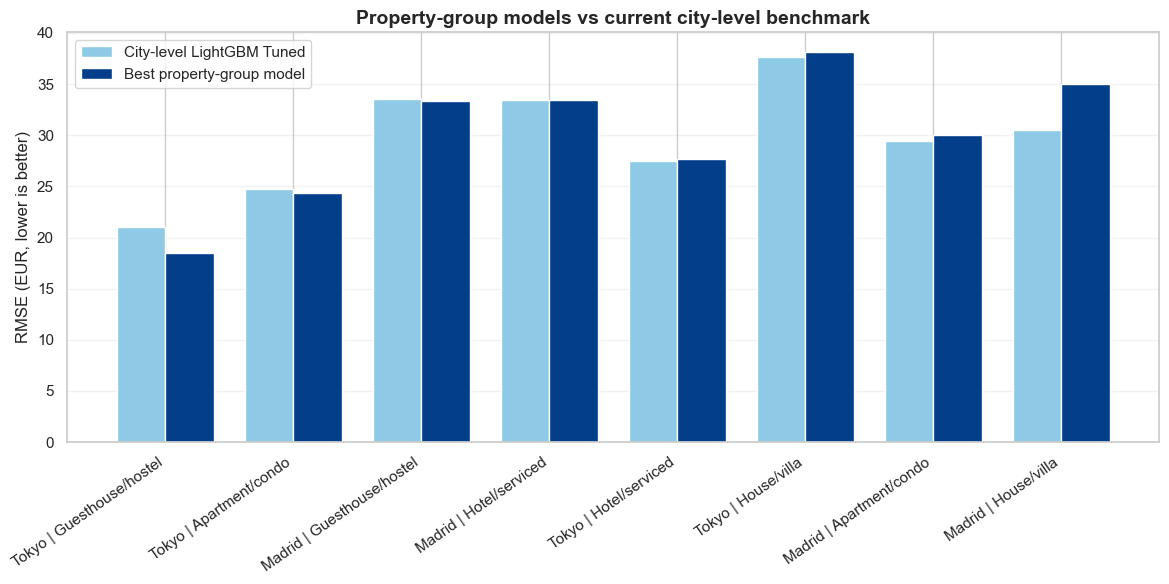

In [10]:
def plot_segment_comparison(comparison: pd.DataFrame) -> None:
    """Plot segmented RMSE against the current city-level benchmark RMSE."""
    if comparison.empty:
        print("No comparison data available.")
        return

    plot_df = comparison.copy()
    plot_df["segment_label"] = plot_df["city"] + " | " + plot_df[SEGMENT_COL]
    plot_df = plot_df.sort_values("rmse_change_vs_city_model")

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(plot_df))
    width = 0.38

    ax.bar(x - width / 2, plot_df["city_level_rmse_eur"], width, label="City-level LightGBM Tuned", color="#8ecae6")
    ax.bar(x + width / 2, plot_df["rmse_eur"], width, label="Best property-group model", color="#023e8a")

    ax.set_title("Property-group models vs current city-level benchmark", fontsize=14, fontweight="bold")
    ax.set_ylabel("RMSE (EUR, lower is better)")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["segment_label"], rotation=35, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

plot_segment_comparison(property_group_comparison)

The bar chart makes the experiment easy to read: if the dark bar is lower than the light bar, the property-group-specific model improved the RMSE for that segment.

---
## 11. Save Outputs

In [11]:
def save_property_group_outputs() -> None:
    """Save the experiment outputs to the project ml_models folder."""
    segment_audit.to_csv(OUTPUT_DIR / "property_group_segment_audit.csv", index=False)
    property_group_results.to_csv(OUTPUT_DIR / "property_group_model_results.csv", index=False)
    property_group_best.to_csv(OUTPUT_DIR / "property_group_best_models.csv", index=False)
    property_group_comparison.to_csv(OUTPUT_DIR / "property_group_vs_city_benchmark.csv", index=False)
    property_group_predictions.to_csv(OUTPUT_DIR / "property_group_model_predictions.csv", index=False)

    print("Saved outputs:")
    for file_name in [
        "property_group_segment_audit.csv",
        "property_group_model_results.csv",
        "property_group_best_models.csv",
        "property_group_vs_city_benchmark.csv",
        "property_group_model_predictions.csv",
    ]:
        path = OUTPUT_DIR / file_name
        print("-", path)

save_property_group_outputs()

Saved outputs:
- C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\property_group_segment_audit.csv
- C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\property_group_model_results.csv
- C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\property_group_best_models.csv
- C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\property_group_vs_city_benchmark.csv
- C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\property_group_model_predictions.csv


This cell saves the full experiment results. The most useful files for discussion are `property_group_best_models.csv` and `property_group_vs_city_benchmark.csv`.

---
## 12. Summary Interpretation

In [12]:
def summarize_property_group_experiment(comparison: pd.DataFrame) -> None:
    """Print a plain-English summary of whether segmentation helped."""
    if comparison.empty:
        print("No comparison available.")
        return

    helped = comparison[comparison["segmented_model_helped"]].copy()
    not_helped = comparison[~comparison["segmented_model_helped"]].copy()

    print(f"Segments tested: {len(comparison)}")
    print(f"Segments where property-group modelling improved RMSE: {len(helped)}")
    print(f"Segments where city-level model remained better/equal: {len(not_helped)}")

    if not helped.empty:
        print("\nLargest RMSE improvements:")
        cols = ["city", SEGMENT_COL, "model", "rmse_change_vs_city_model", "mae_change_vs_city_model", "r2_change_vs_city_model"]
        display(helped.sort_values("rmse_change_vs_city_model")[cols])

    if not not_helped.empty:
        print("\nSegments where segmentation did not improve RMSE:")
        cols = ["city", SEGMENT_COL, "model", "rmse_change_vs_city_model", "mae_change_vs_city_model", "r2_change_vs_city_model"]
        display(not_helped.sort_values("rmse_change_vs_city_model")[cols])

summarize_property_group_experiment(property_group_comparison)

Segments tested: 8
Segments where property-group modelling improved RMSE: 3
Segments where city-level model remained better/equal: 5

Largest RMSE improvements:


,city,property_group,model,rmse_change_vs_city_model,mae_change_vs_city_model,r2_change_vs_city_model
4,Tokyo,Guesthouse/hostel,CatBoost Tuned,-2.5356,-1.1015,0.0477
5,Tokyo,Apartment/condo,LightGBM Tuned,-0.3606,-0.3216,0.0074
1,Madrid,Guesthouse/hostel,LightGBM Tuned,-0.2722,-2.6237,0.0044



Segments where segmentation did not improve RMSE:


,city,property_group,model,rmse_change_vs_city_model,mae_change_vs_city_model,r2_change_vs_city_model
2,Madrid,Hotel/serviced,CatBoost Tuned,0.0416,-0.5614,-0.0005
6,Tokyo,Hotel/serviced,CatBoost Tuned,0.2067,0.0349,-0.0029
7,Tokyo,House/villa,LightGBM Tuned,0.4870,0.6268,-0.0078
0,Madrid,Apartment/condo,LightGBM Tuned,0.5766,0.2168,-0.0090
3,Madrid,House/villa,CatBoost Tuned,4.5225,2.1895,-0.0735


This final cell turns the experiment into an interpretation. The result should be used as evidence rather than an assumption: segmentation may improve larger homogeneous groups, but smaller groups can become unstable because they have less training data.